# Phase 2 — Feature Engineering

**What is this notebook?** A guided read-through of how the 182-column feature matrix was built and how it was cut down to the two final feature sets: **58 features for LightGBM** and **30 WOE-binned features for the logistic scorecard**.

**Why a read-through and not the pipeline itself?** The pipeline is scripted (`scripts/run_phase2.py` + `scripts/run_phase2_null_chunks.py`) because feature engineering must be *reproducible and restartable*, not trapped in notebook cells. This notebook loads the pipeline's saved artifacts and explains every decision — the notebook is the tour, the scripts are the factory.

**The three layers (and what each one proves):**
1. **Aggregations** — one row per applicant from `bureau`, `bureau_balance`, `previous_application`. Proves we can think like an analyst: the auxiliary tables carry most of the differentiating signal.
2. **Domain ratios** — leverage, payment burden, employment stability, implied term. Proves we understand *lending*, not just ML. Each has a one-line credit-officer justification.
3. **Selection discipline** — near-constant drop → correlation drop → null-importance filter. Proves we can say *no*: a feature that can't beat its own noise floor is memorizing, not predicting.

**Leakage rule used throughout:** stateless transforms (sentinels, ratios, flags) are safe anywhere; **stateful** ones (bins, thresholds, importance distributions) were fit on the **dev set only** and merely applied to the holdout. The pipeline-integrity check at the end confirms nothing crossed the boundary.

In [1]:
import sys, os, json
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.constants import ID_COL, TARGET_COL, DATA_PROCESSED, TABLES_DIR
from src.data.load import load_dev_ids

features = pd.read_parquet(os.path.join(DATA_PROCESSED, "features_full.parquet"))
dev = features[features[ID_COL].isin(set(load_dev_ids()))].reset_index(drop=True)
print(f"full matrix: {features.shape[0]:,} rows × {features.shape[1]} cols | dev: {len(dev):,} rows")

full matrix: 307,511 rows × 182 cols | dev: 246,008 rows


## 1. What the aggregations added

Per-applicant summaries of the auxiliary tables, using only the boring five functions (`min, max, mean, sum, count`). Naming is `<table>_<field>_<stat>` so the manifest is self-documenting.

Key design choices:
- **`bureau_balance` two-stage rollup**: 27M monthly rows → per-loan (max DPD bucket, share of delinquent months) → per-applicant. "Worst delinquency *ever*" is a far cleaner signal than "current status".
- **NaN policy after the join**: counts/sums for no-history applicants → 0 (they factually have zero prior loans); means/maxes → NaN (the mean of an empty history is undefined — the flag carries the signal).
- **Two separate history flags**, because they point in *opposite* directions (EDA #11 vs #12): no bureau file = riskiest group (10.1% default); no prior HC application = safest (6.0%).

In [2]:
agg_cols = [col for col in dev.columns if col.startswith(("bureau_", "prev_"))]
print(f"{len(agg_cols)} aggregate features. Sample of the summary table:")
pd.read_csv(os.path.join(TABLES_DIR, "aggregation_summary.csv"), index_col=0).head(10)

41 aggregate features. Sample of the summary table:


,count,mean,std,min,max,missing_share
bureau_utilization,209902.0,0.282193,4.821424e-01,-175.289231,5.842604e+00,0.146768
bureau_days_credit_max,210764.0,-489.689169,5.383596e+02,-2922.000000,0.000000e+00,0.143264
prev_refusal_share,232834.0,0.111101,1.845148e-01,0.000000,1.000000e+00,0.053551
prev_amt_application_max,232834.0,374542.815249,4.219403e+05,0.000000,5.850000e+06,0.053551
prev_cnt_payment_mean,232490.0,14.535749,8.431137e+00,0.000000,7.200000e+01,0.054949
prev_req_vs_granted_mean,232643.0,0.968911,1.712547e-01,0.000000,5.467110e+00,0.054328
bureau_credit_max,210763.0,975327.161281,1.976085e+06,0.000000,1.701000e+08,0.143268
bureau_max_overdue_amt,146940.0,9817.192348,4.086996e+05,0.000000,1.159872e+08,0.402702
prev_req_vs_granted_max,232643.0,1.114033,3.126504e-01,0.000000,2.000000e+01,0.054328
prev_cnt_payment_max,232490.0,24.106116,1.672030e+01,0.000000,8.400000e+01,0.054949


## 2. Domain ratios — the credit-officer features

| Feature | Why an underwriter cares |
|---|---|
| `credit_income_ratio` | Leverage: years of gross income the loan represents |
| `annuity_income_ratio` | Payment burden (DTI): repayment vs income flow |
| `payment_rate` | Annuity/credit — inverse of term |
| `credit_goods_ratio` | Financing more than the goods = no skin in the game |
| `employment_stability` | Share of life in current job |
| `term_years` | Implied term, capped [0.5, 7] — **also the Phase 4 cost-model input** |
| `ext_source_mean` / `_min` | Consensus and worst-case across the three bureau scores |

Preprocessing policy (justified omissions — see `reports/FEATURE_ENGINEERING.md`): **no scaling** (trees split on rank order; WOE *is* the scorecard's scaling), **no imputation** (LightGBM routes NaN natively; WOE gives NaN its own bin — imputing would destroy the missingness signal from EDA finding #3).

## 3. The selection funnel: 179 → 58

| Step | Dropped | Rule (frozen before running) |
|---|---|---|
| Near-constant | 19 | one value > 99.5% of non-null rows |
| Spearman > 0.98 | 28 | keep the twin with higher univariate AUC |
| Null importance | 75 | real gain must beat the feature's own null 95th percentile (50 shuffled-target runs) |

Highlights the funnel caught:
- Our **own engineered duplicates** (`age_years` vs `DAYS_BIRTH`, ρ = −1.000) — the rule doesn't play favorites.
- The housing `_AVG/_MODE/_MEDI` triplets (18 of the 28 correlation drops).
- A found interaction: `is_pensioner` ≈ ¬`FLAG_EMP_PHONE` (ρ = −0.9998) — pensioners are exactly the applicants without a work phone.
- `credit_income_ratio` failed null importance — **consistent with EDA #8** (leverage deciles were flat). Two independent methods, one conclusion.

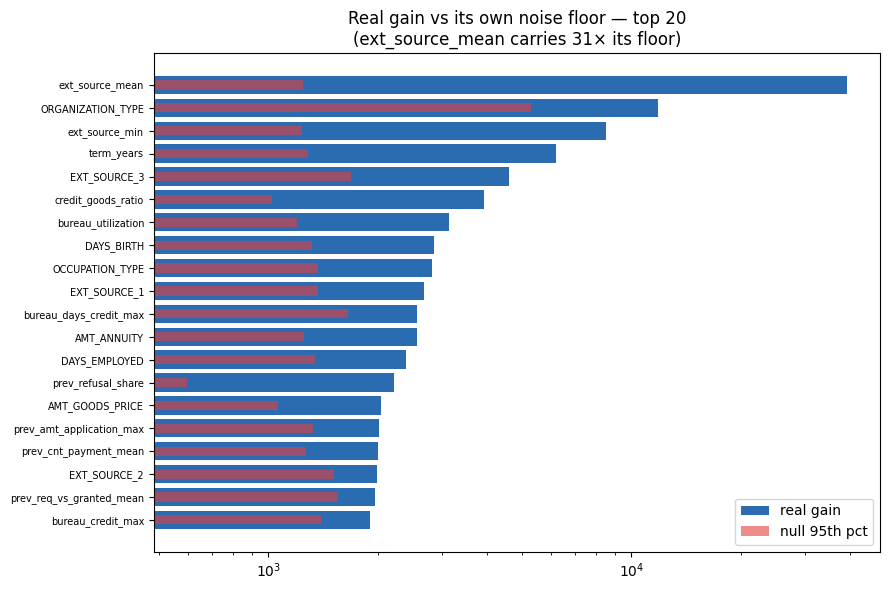

final LightGBM set: 58 features | pipeline: ['near_constant>0.995', 'spearman>0.98', 'null_importance_p95_50runs']


In [3]:
rep = pd.read_csv(os.path.join(TABLES_DIR, "null_importance_report.csv"))
fig, ax = plt.subplots(figsize=(9, 6))
top = rep.head(20)
ax.barh(np.arange(len(top)), top["real_gain"], color="#2b6cb0", label="real gain")
ax.barh(np.arange(len(top)), top["null_gain_p95"], color="#e53e3e", alpha=0.6, height=0.4, label="null 95th pct")
ax.set_yticks(np.arange(len(top)), top["feature"], fontsize=7); ax.invert_yaxis()
ax.set_xscale("log"); ax.legend()
ax.set_title("Real gain vs its own noise floor — top 20\n(ext_source_mean carries 31× its floor)")
plt.tight_layout(); plt.show()

kept = json.load(open(os.path.join(DATA_PROCESSED, "lgbm_features.json")))
print(f"final LightGBM set: {kept['n_features']} features | pipeline: {kept['pipeline']}")

### Does 58 actually match 133? (verified, not assumed)

The spec allows fewer than the 150–300 target *"if performance holds"* — a conditional, so we tested it: fold-1 AUC with the selected **58 = 0.7720** vs all 133 post-correlation candidates = 0.7712 (Δ = −0.0009, within noise). Fewer features, same performance — the *better* result per spec, and now an empirical claim (`selection_performance_check.json`).

## 4. WOE/IV for the scorecard (Siddiqi 2006)

Each feature → 5 quantile bins (NaN = its own bin; rare categories → Other), values replaced by `WOE = ln(%good/%bad)`, screened by Information Value ∈ [0.02, 0.5]. Result: **30 scorecard features**.

**The IV audit fired — and the rule held.** `ext_source_mean` scored IV = 0.572 > 0.50 and was flagged per the frozen rule. Audit conclusion: *not leakage* — a composite of the three strongest legitimate predictors naturally exceeds the ceiling (EXT_SOURCE_3 alone: 0.31). It stays **out of the scorecard** because the rule is the rule; no signal is lost since its components are individually in-range and a linear model weights them itself. It remains in the LightGBM set, where the IV rule does not apply.

**Phase 3 discipline note:** the saved `WOEBinner` was fit on full dev — for reporting and the final holdout transform only. **CV in Phase 3 must refit the binner inside each fold** (fit on 4, transform the 5th), per the Phase 0 leakage checklist.

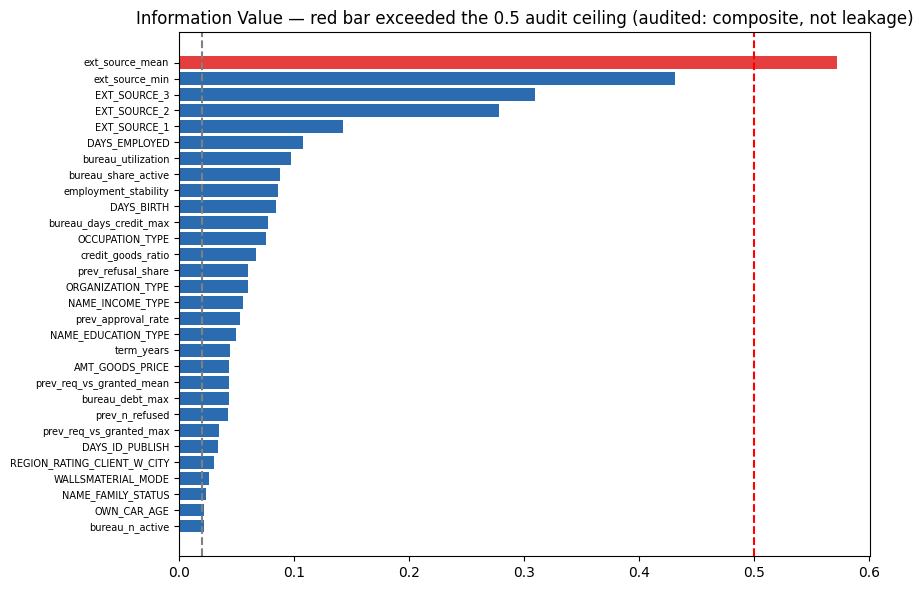

In [4]:
iv = pd.read_csv(os.path.join(TABLES_DIR, "woe_iv_table.csv"))
fig, ax = plt.subplots(figsize=(9, 6))
top = iv.head(30)
ax.barh(np.arange(len(top)), top["iv"], color=["#e53e3e" if v > 0.5 else "#2b6cb0" for v in top["iv"]])
ax.set_yticks(np.arange(len(top)), top["feature"], fontsize=7); ax.invert_yaxis()
ax.axvline(0.02, ls="--", c="gray"); ax.axvline(0.5, ls="--", c="red")
ax.set_title("Information Value — red bar exceeded the 0.5 audit ceiling (audited: composite, not leakage)")
plt.tight_layout(); plt.show()

## 5. Validation gates — all passed

| Check | Result | Meaning |
|---|---|---|
| Pipeline integrity (dev vs holdout, final features) | AUC **0.5024** | no statistic crossed the split boundary |
| Sanity fold-1 AUC, default params | **0.7720** | learnable, inside the 0.76–0.80 corridor |
| Leakage alarm (> 0.81) | not triggered | nothing too good to be true |
| Aggregates vs hand computation | exact match | join logic correct |
| TARGET alignment after joins | exact match | rows never scrambled |
| 23 unit tests | pass | WOE math hand-verified, NaN/unseen-category handling, gender quarantine |

One catch worth recording: the `MONOTONIC_FEATURES` verification found a dead reference (`bureau_days_overdue_max` did not survive selection) — fixed to `bureau_bb_share_dpd_max` *before* it could silently no-op in Phase 5. Verifying claims beats trusting them.

**Next (Phase 3):** logistic scorecard on the 30 WOE features (binner refit per fold) benchmarked against Optuna-tuned LightGBM on the 58 — same frozen folds, honest comparison.

In [5]:
print(json.load(open(os.path.join(TABLES_DIR, "integrity_check_phase2.json")))["interpretation"])
print(json.load(open(os.path.join(TABLES_DIR, "sanity_auc_phase2.json"))))

PASS — no pipeline leakage detected (AUC ≈ 0.50 as expected).
{'fold1_auc': 0.7720209830520474, 'expected_range': [0.76, 0.8], 'leakage_alarm_above': 0.81, 'note': 'sanity tripwire only — Phase 3 owns real numbers', 'alarm': False}
